In [1]:
import sys
sys.path.append('../')
from utils_models import *

In [30]:
with open('../pickles/mesolve_final_combined.pkl', 'rb') as file:
    results = pickle.load(file)


In [38]:
tot_time =733 + 200
tlist = np.linspace(0, tot_time, tot_time)



num_time_steps = tot_time

zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
states_ideal  = [zero,
                one,
                (zero +  one).unit(),
                (zero - one).unit(),
                # (zero + 1j * one).unit(),
                # (zero - 1j * one).unit(),
                ]


def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,dm_ideal in zip(dms,states_ideal):
        new_dm = gate*dm*gate.dag()
        fid.append(qutip.fidelity(new_dm, dm_ideal))
        # fid.append(qutip.fidelity(dm, gate*dm_ideal))
    return 1-sum(fid)/len(fid)


from scipy.optimize import minimize

infidelity1 = []
phase1 = []
for idx in tqdm(range(num_time_steps)):
    dms = [result.states_dressed_to_2_level_dm[idx] for result in results[2:6]]
    def objective_function(phase):
        return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
    initial_phase = [0.0]
    bounds = [(0, 2 * 3.141592653589793)]
    opt_result = minimize(objective_function, initial_phase,method="COBYLA")
    infidelity1.append(opt_result.fun)
    phase1.append(opt_result.x[0])


infidelity2 = []
phase2 = []
for idx in tqdm(range(num_time_steps)):
    dms = [result.states_dressed_to_2_level_dm[idx] for result in results[12:16]]
    def objective_function(phase):
        return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
    initial_phase = [0.0]
    bounds = [(0, 2 * 3.141592653589793)]
    opt_result = minimize(objective_function, initial_phase,method="COBYLA")
    infidelity2.append(opt_result.fun)
    phase2.append(opt_result.x[0])



100%|██████████| 933/933 [00:24<00:00, 37.90it/s]


Text(0.5, 0, 'ns')

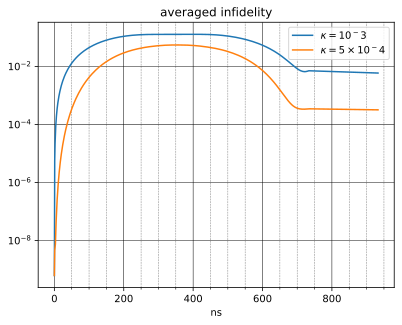

In [39]:
plt.plot(results[0].times,infidelity1,label = rf'$\kappa = 10^{-3}$')
plt.plot(results[0].times,infidelity2,label = rf'$\kappa = 5 \times 10^{-4}$')

plt.grid(which='major', linestyle='-', linewidth='0.5', color='black')
plt.minorticks_on()
plt.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')

plt.legend()

plt.yscale('log')
plt.title("averaged infidelity")
plt.xlabel("ns")

Text(0.5, 0, 'ns')

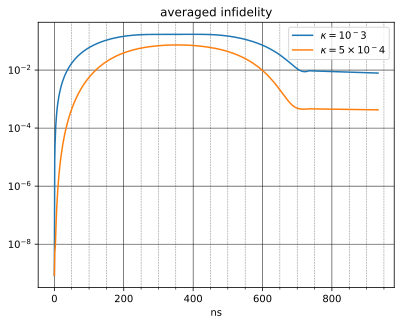

In [36]:
plt.plot(results[0].times,infidelity1,label = rf'$\kappa = 10^{-3}$')
plt.plot(results[0].times,infidelity2,label = rf'$\kappa = 5 \times 10^{-4}$')

plt.grid(which='major', linestyle='-', linewidth='0.5', color='black')
plt.minorticks_on()
plt.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')

plt.legend()

plt.yscale('log')
plt.title("averaged infidelity")
plt.xlabel("ns")

Processing through tlist: 100%|██████████| 933/933 [00:02<00:00, 389.16it/s]es/matplotlib/cbook/__init__.py: 1335


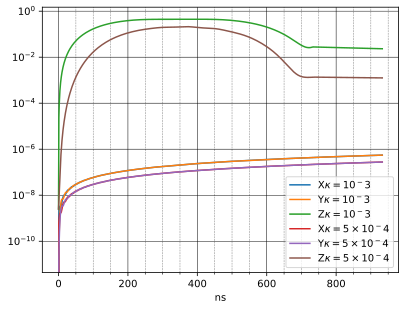

In [37]:
# colors = [(0.9, 0.9, 0.4), (0.5*0.5, 0.7*0.5, 0.5*0.5), (0.7, 0.6, 0.7)]
# linestyles = [(0,(3,1,1,1)),'-',(0,(5,2,5,2))]
times = results[0].times
for pauli_results, phase, prefix in zip(
    [[results[2],results[3],results[8],results[9]], [results[12],results[13],results[18],results[19]]],
    [phase1,phase2],
    [rf'$\kappa = 10^{-3}$', rf'$\kappa = 5 \times 10^{-4}$']
    ):
    errors = {
        'X': [],
        'Y': [],
        'Z': []
    }
    inner_product_vals_dict = {
        'X': [],
        'Y': [],
        'Z': []
    }

    Paulis = [qutip.sigmax(),qutip.sigmay(),qutip.sigmaz()]


    dms_ideal = [
        zero * zero.dag(),
        one * one.dag(),
        zero * one.dag(),
        one * zero.dag()
    ]
    for idx in tqdm(range(len(times)), desc='Processing through tlist'):
        dms = [pauli_results[0].states_dressed_to_2_level_dm[idx],
            pauli_results[1].states_dressed_to_2_level_dm[idx],
            pauli_results[2].states_dressed_to_2_level_dm[idx],
            pauli_results[3].states_dressed_to_2_level_dm[idx]]
        gate = qutip.qip.operations.phasegate(theta=  phase[idx])
        for P, Pauli in zip(['X','Y','Z'],Paulis):
            inner_product_vals = []
            for dm_ideal, dm in zip(
                dms_ideal,
                [dms[0],dms[1],dms[2],dms[3]]
                ):
                the_second_term = Pauli * dm_ideal * Pauli.dag()                    
                dm = gate * dm * gate.dag()
                inner_product = (the_second_term * dm.dag()).tr()
                inner_product_vals.append(inner_product)
            errors[P].append(sum(inner_product_vals)/len(inner_product_vals))
            inner_product_vals_dict[P].append(inner_product_vals)

    plt.plot(times,errors['X'],label = 'X' + prefix)
    plt.plot(times,errors['Y'],label = 'Y' + prefix)
    plt.plot(times,errors['Z'],label = 'Z' + prefix)


plt.xlabel("ns")
plt.yscale('log')

plt.grid(which='major', linestyle='-', linewidth='0.5', color='black')
plt.minorticks_on()
plt.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')

plt.legend()


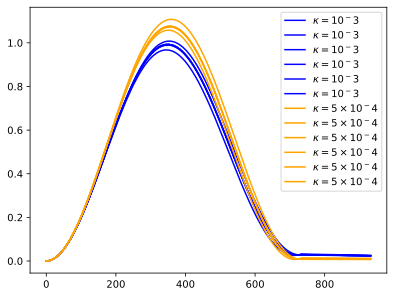

In [46]:
for computational_results, prefix, color in zip(
    [results[2:8], results[12:18]],
    [rf'$\kappa = 10^{-3}$', rf'$\kappa = 5 \times 10^{-4}$'],
    ['blue','orange']
    ):
    for result in computational_results:
        plt.plot(result.expect[1],color = color,label = prefix)
plt.legend()

    

(0.0, 0.1)

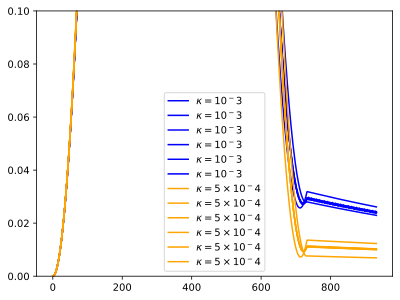

In [47]:
for computational_results, prefix, color in zip(
    [results[2:8], results[12:18]],
    [rf'$\kappa = 10^{-3}$', rf'$\kappa = 5 \times 10^{-4}$'],
    ['blue','orange']
    ):
    for result in computational_results:
        plt.plot(result.expect[1],color = color,label = prefix)
plt.legend()
plt.ylim(0,0.1)

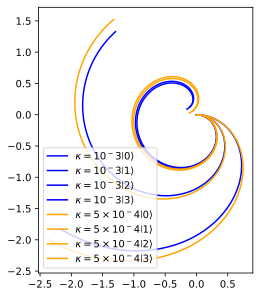

In [61]:
for eigenstate_results, prefix, color in zip(
    [[results[0],results[2],results[3],results[1]], [results[10],results[12],results[13],results[11]]],
    [rf'$\kappa = 10^{-3}$', rf'$\kappa = 5 \times 10^{-4}$'],
    ['blue','orange']
    ):
    t_stop = 733
    first_dominant_freq =find_dominant_frequency(eigenstate_results[0].expect[0][:t_stop],tlist[:t_stop])
    for i, result in enumerate(eigenstate_results):
        alpha = result.expect[0][:t_stop]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist[:t_stop])
        plt.plot(-alpha.imag,alpha.real,color=color,label = prefix + rf'$\left|{i}\right>$')
plt.legend()
plt.gca().set_aspect('equal', 'box')

 /var/folders/yv/8f1w22v95lj4r3b_62lwrtvr0000gn/T/ipykernel_59425/1389590265.py: 44

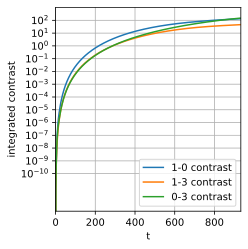

In [62]:
t_stop = 733
first_dominant_freq = find_dominant_frequency(results[0].expect[0][:t_stop],tlist[:t_stop])

plt.figure(figsize=(3+3/8,3+3/8))
kappa_val = 1e-3

alpha1 = results[2].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
alpha0 = results[0].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
alpha3 = results[1].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)


squared_diff = np.square(abs(alpha0-alpha1))
integrals = [0.0]
for i in range(1,len(tlist)):
    integrals.append(integrals[i-1]+
                        (tlist[i]-tlist[i-1])*np.sqrt(kappa_val)*squared_diff[i]
                        )
    
plt.plot(tlist,integrals,label='1-0 contrast')

squared_diff = np.square(abs(alpha3-alpha1))
integrals = [0.0]
for i in range(1,len(tlist)):
    integrals.append(integrals[i-1]+
                        (tlist[i]-tlist[i-1])*np.sqrt(kappa_val)*squared_diff[i]
                        )
    
plt.plot(tlist,integrals,label='1-3 contrast')


squared_diff = np.square(abs(alpha3-alpha0))
integrals = [0.0]
for i in range(1,len(tlist)):
    integrals.append(integrals[i-1]+
                        (tlist[i]-tlist[i-1])*np.sqrt(kappa_val)*squared_diff[i]
                        )
    
plt.plot(tlist,integrals,label='0-3 contrast')



plt.legend(loc='lower right')
plt.yscale('log')
plt.ylim(0,1e3)
plt.yticks([1e-10,1e-9,1e-8,1e-7,1e-6,1e-5,1e-4,1e-3,1e-2,1e-1,1,1e1,1e2])
plt.xlim(0,tot_time)
plt.grid()
plt.tight_layout()
plt.xlabel('t')
plt.ylabel('integrated contrast')
# plt.savefig("fig06_integral.pdf", format='pdf', bbox_inches='tight')
plt.show()



 /var/folders/yv/8f1w22v95lj4r3b_62lwrtvr0000gn/T/ipykernel_59425/1977859452.py: 44

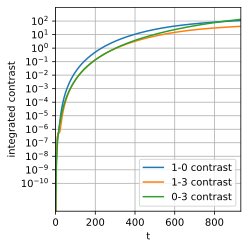

In [64]:
t_stop = 733
first_dominant_freq = find_dominant_frequency(results[10].expect[0][:t_stop],tlist[:t_stop])

plt.figure(figsize=(3+3/8,3+3/8))
kappa_val = 5e-4

alpha1 = results[12].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
alpha0 = results[10].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
alpha3 = results[11].expect[-2]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)


squared_diff = np.square(abs(alpha0-alpha1))
integrals = [0.0]
for i in range(1,len(tlist)):
    integrals.append(integrals[i-1]+
                        (tlist[i]-tlist[i-1])*np.sqrt(kappa_val)*squared_diff[i]
                        )
    
plt.plot(tlist,integrals,label='1-0 contrast')

squared_diff = np.square(abs(alpha3-alpha1))
integrals = [0.0]
for i in range(1,len(tlist)):
    integrals.append(integrals[i-1]+
                        (tlist[i]-tlist[i-1])*np.sqrt(kappa_val)*squared_diff[i]
                        )
    
plt.plot(tlist,integrals,label='1-3 contrast')


squared_diff = np.square(abs(alpha3-alpha0))
integrals = [0.0]
for i in range(1,len(tlist)):
    integrals.append(integrals[i-1]+
                        (tlist[i]-tlist[i-1])*np.sqrt(kappa_val)*squared_diff[i]
                        )
    
plt.plot(tlist,integrals,label='0-3 contrast')



plt.legend(loc='lower right')
plt.yscale('log')
plt.ylim(0,1e3)
plt.yticks([1e-10,1e-9,1e-8,1e-7,1e-6,1e-5,1e-4,1e-3,1e-2,1e-1,1,1e1,1e2])
plt.xlim(0,tot_time)
plt.grid()
plt.tight_layout()
plt.xlabel('t')
plt.ylabel('integrated contrast')
# plt.savefig("fig06_integral.pdf", format='pdf', bbox_inches='tight')
plt.show()

